# Mall Customer Segmentation — Unsupervised Learning Project
## Major Project | Unsupervised Machine Learning
---
**Algorithm:** K-Means Clustering  
**Dataset:** Mall Customer Segmentation Dataset (1000 Records)  
**Goal:** Discover hidden customer groups based on Age, Annual Income, and Spending Score  

---
### Table of Contents
1. Import Libraries  
2. Load & Explore Dataset  
3. Data Preprocessing  
4. Exploratory Data Analysis (EDA)  
5. Finding Optimal K (Elbow Method)  
6. K-Means Model Training  
7. Cluster Visualization  
8. Cluster Interpretation  
9. Abstract  


## 1. Import Libraries

In [13]:
import pandas as pd                          # For loading and manipulating tabular data
import matplotlib.pyplot as plt              # For creating plots and charts
import seaborn as sns                        # For beautiful statistical visualizations
import warnings

from sklearn.cluster import KMeans           # The K-Means clustering algorithm
from sklearn.preprocessing import StandardScaler  # Normalize features to same scale
from sklearn.metrics import silhouette_score      # Measure clustering quality
from sklearn.decomposition import PCA             # Reduce dimensions for 2D visualization

# SECTION 1: IMPORTING LIBRARIES
# We import all the tools we need for data manipulation, visualization,
# and building our unsupervised learning model (K-Means Clustering).

warnings.filterwarnings('ignore')            # Suppress non-critical warnings

# Set a consistent visual style for all plots
sns.set_theme(style="darkgrid", palette="muted", font_scale=1.2)
plt.rcParams['figure.dpi'] = 100

print("All libraries imported successfully!")

All libraries imported successfully!


## 2. Load & Explore Dataset

In [14]:
# SECTION 2: LOAD AND EXPLORE THE DATASET
# We first load the CSV file into a pandas DataFrame.
# Then we look at its shape, column names, data types, and sample rows
# to understand what we are working with before doing anything to it.

# Load the dataset — change the path if your file is in a different location
df = pd.read_csv("store_customers.csv")

print("=" * 55)
print("DATASET OVERVIEW")
print("=" * 55)
print(f"  Shape       : {df.shape[0]} rows × {df.shape[1]} columns")
print(f"  Columns     : {df.columns.tolist()}")
print()

# Display the first 10 rows to get a feel for the data
print("First 10 rows:")
df.head(10)


DATASET OVERVIEW
  Shape       : 1000 rows × 5 columns
  Columns     : ['CustomerID', 'Gender', 'Age', 'Annual Income (k$)', 'Spending Score (1-100)']

First 10 rows:


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1000,M,39.0,59.9,58.0
1,1001,M,34.0,48.4,37.0
2,1002,F,40.0,70.5,26.0
3,1003,F,47.0,81.1,30.0
4,1004,F,33.0,42.1,58.0
5,1005,M,33.0,36.7,73.0
6,1006,F,48.0,90.4,34.0
7,1007,F,41.0,74.8,35.0
8,1008,F,31.0,42.3,43.0
9,1009,M,39.0,48.6,61.0


In [15]:
# Statistical Summary
# .describe() gives us count, mean, standard deviation, min, max, and
# the 25th/50th/75th percentile for each numeric column.
# This helps us spot outliers and understand the data range.

print("Statistical Summary:")
df.describe().round(2)


Statistical Summary:


,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,1000.00,994.00,996.00,994.00
mean,1499.50,38.94,57.15,42.65
std,288.82,13.40,28.63,20.10
min,1000.00,18.00,15.00,1.00
25%,1249.75,30.00,34.98,31.00
50%,1499.50,36.00,49.00,47.00
75%,1749.25,44.00,79.40,57.00
max,1999.00,80.00,144.10,92.00


In [16]:
# Check for Missing Values
# Real-world datasets almost always have missing values.
# We must find them before they silently corrupt our model.

print("Missing Values per Column:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)
print()
print(f"Total missing cells: {df.isnull().sum().sum()}")


Missing Values per Column:
                        Missing Count  Missing %
CustomerID                          0        0.0
Gender                              3        0.3
Age                                 6        0.6
Annual Income (k$)                  4        0.4
Spending Score (1-100)              6        0.6

Total missing cells: 19


## 3. Data Preprocessing

In [17]:
# SECTION 3: DATA PREPROCESSING
# Preprocessing = cleaning and preparing data before feeding it to the model.
#
# Steps we take:
#   1. Drop rows with missing values (only ~1.5% of data, safe to remove)
#   2. Encode the Gender column (M → 0, F → 1) so it becomes numeric
#   3. Drop CustomerID — it is just an identifier, not a useful feature
#   4. Scale (normalize) all features so no single column dominates
#      (e.g., Annual Income ranges 15–144 while Spending Score is 1–100)

# Step 1: Drop rows with ANY missing value
df_clean = df.dropna().reset_index(drop=True)
print(f"Rows after dropping nulls: {len(df_clean)} (removed {len(df) - len(df_clean)} rows)")

# Step 2: Encode Gender as numeric (Male=0, Female=1)
df_clean['Gender_Encoded'] = df_clean['Gender'].map({'M': 0, 'F': 1})
print("Gender encoded: M -> 0, F -> 1")

# Step 3: Select the features we will use for clustering
# We drop CustomerID (just an ID) and the original Gender string column
features = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_Encoded']
X = df_clean[features].copy()
print(f"Features selected: {features}")

# Step 4: Scale features using StandardScaler
# StandardScaler transforms each feature to have: mean = 0, std = 1
# This ensures K-Means (which is distance-based) treats all features equally
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print()
print("Scaling complete. Sample scaled values:")
print(pd.DataFrame(X_scaled, columns=features).head(5).round(3))


Rows after dropping nulls: 982 (removed 18 rows)
Gender encoded: M -> 0, F -> 1
Features selected: ['Age', 'Annual Income (k$)', 'Spending Score (1-100)', 'Gender_Encoded']

Scaling complete. Sample scaled values:
     Age  Annual Income (k$)  Spending Score (1-100)  Gender_Encoded
0  0.003               0.090                   0.766          -1.042
1 -0.370              -0.312                  -0.279          -1.042
2  0.078               0.460                  -0.826           0.960
3  0.600               0.830                  -0.627           0.960
4 -0.444              -0.532                   0.766           0.960


## 4. Exploratory Data Analysis (EDA)

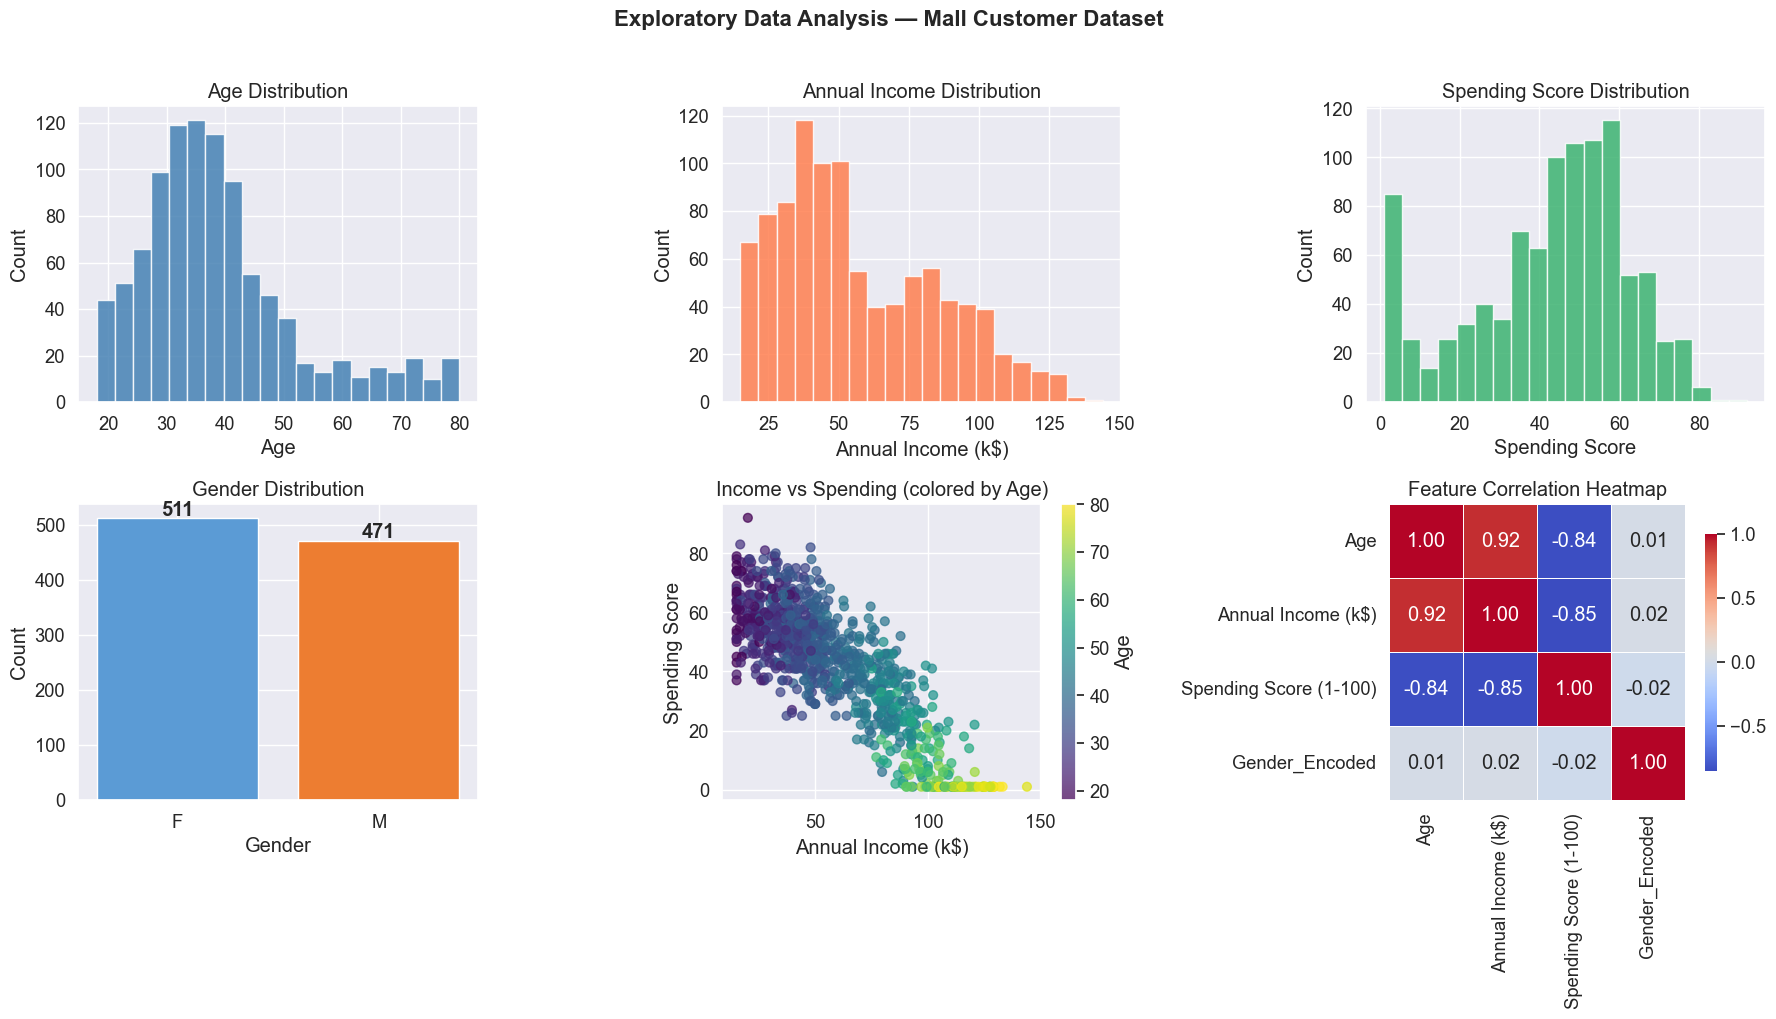

EDA plots saved as eda_plots.png


In [18]:
# SECTION 4: EXPLORATORY DATA ANALYSIS (EDA)
# Before modeling, we visualize the raw data to:
#   - Understand distributions of each feature
#   - See relationships between features
#   - Spot natural groupings visually

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle("Exploratory Data Analysis — Mall Customer Dataset", fontsize=16, fontweight='bold', y=1.01)

# Plot 1: Age Distribution
axes[0,0].hist(df_clean['Age'], bins=20, color='steelblue', edgecolor='white', alpha=0.85)
axes[0,0].set_title("Age Distribution")
axes[0,0].set_xlabel("Age")
axes[0,0].set_ylabel("Count")

# Plot 2: Annual Income Distribution
axes[0,1].hist(df_clean['Annual Income (k$)'], bins=20, color='coral', edgecolor='white', alpha=0.85)
axes[0,1].set_title("Annual Income Distribution")
axes[0,1].set_xlabel("Annual Income (k$)")
axes[0,1].set_ylabel("Count")

#  Plot 3: Spending Score Distribution 
axes[0,2].hist(df_clean['Spending Score (1-100)'], bins=20, color='mediumseagreen', edgecolor='white', alpha=0.85)
axes[0,2].set_title("Spending Score Distribution")
axes[0,2].set_xlabel("Spending Score")
axes[0,2].set_ylabel("Count")

# Plot 4: Gender Count
gender_counts = df_clean['Gender'].value_counts()
axes[1,0].bar(gender_counts.index, gender_counts.values, color=['#5b9bd5','#ed7d31'], edgecolor='white')
axes[1,0].set_title("Gender Distribution")
axes[1,0].set_xlabel("Gender")
axes[1,0].set_ylabel("Count")
for i, v in enumerate(gender_counts.values):
    axes[1,0].text(i, v + 5, str(v), ha='center', fontweight='bold')

# Plot 5: Income vs Spending Scatter
scatter = axes[1,1].scatter(
    df_clean['Annual Income (k$)'],
    df_clean['Spending Score (1-100)'],
    c=df_clean['Age'], cmap='viridis', alpha=0.7, s=40
)
fig.colorbar(scatter, ax=axes[1,1], label='Age')
axes[1,1].set_title("Income vs Spending (colored by Age)")
axes[1,1].set_xlabel("Annual Income (k$)")
axes[1,1].set_ylabel("Spending Score")

# Plot 6: Correlation Heatmap
corr = df_clean[['Age','Annual Income (k$)','Spending Score (1-100)','Gender_Encoded']].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', ax=axes[1,2],
            linewidths=0.5, square=True, cbar_kws={'shrink': 0.8})
axes[1,2].set_title("Feature Correlation Heatmap")

plt.tight_layout()
plt.savefig("eda_plots.png", bbox_inches='tight', dpi=120)
plt.show()
print("EDA plots saved as eda_plots.png")


## 5. Finding Optimal K — Elbow Method & Silhouette Score

  K= 2 | Inertia:    1995.6 | Silhouette: 0.4467
  K= 3 | Inertia:    1287.9 | Silhouette: 0.4492
  K= 4 | Inertia:     968.8 | Silhouette: 0.4349
  K= 5 | Inertia:     720.0 | Silhouette: 0.4549
  K= 6 | Inertia:     589.1 | Silhouette: 0.4665
  K= 7 | Inertia:     498.4 | Silhouette: 0.4254
  K= 8 | Inertia:     429.7 | Silhouette: 0.3797
  K= 9 | Inertia:     393.9 | Silhouette: 0.3532
  K=10 | Inertia:     364.6 | Silhouette: 0.3402


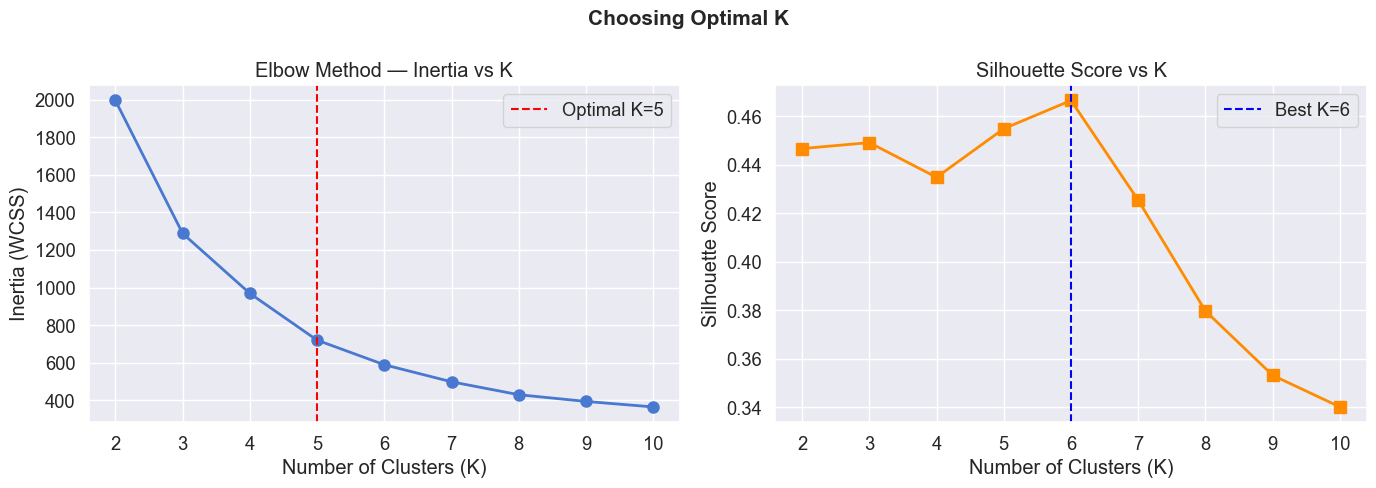


Best K by Silhouette: 6
Plot saved as elbow_silhouette.png


In [19]:
# SECTION 5: FINDING THE OPTIMAL NUMBER OF CLUSTERS (K)
#
# K-Means requires us to specify how many clusters (K) to create.
# We use TWO methods to determine the best K:
#
#   1. ELBOW METHOD:
#      We run K-Means for K = 1 to 10, and plot the "inertia" (within-cluster
#      sum of squared distances). The elbow point — where the curve bends —
#      is the best K because adding more clusters beyond that gives little gain.
#
#   2. SILHOUETTE SCORE:
#      Silhouette score measures how well each point fits its own cluster
#      vs neighboring clusters. Score range: [-1, 1]. Higher = better.

inertias = []
silhouette_scores = []
K_range = range(2, 11)    # We test K from 2 to 10

for k in K_range:
    # Train K-Means with 'k' clusters
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    km.fit(X_scaled)
    
    inertias.append(km.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, km.labels_))
    print(f"  K={k:2d} | Inertia: {km.inertia_:9.1f} | Silhouette: {silhouette_score(X_scaled, km.labels_):.4f}")

# ─ Plot ───
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Choosing Optimal K", fontsize=15, fontweight='bold')

# Elbow Plot
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].axvline(x=5, color='red', linestyle='--', linewidth=1.5, label='Optimal K=5')
axes[0].set_title("Elbow Method — Inertia vs K")
axes[0].set_xlabel("Number of Clusters (K)")
axes[0].set_ylabel("Inertia (WCSS)")
axes[0].legend()

# Silhouette Plot
axes[1].plot(K_range, silhouette_scores, 'rs-', linewidth=2, markersize=8, color='darkorange')
best_k_sil = list(K_range)[silhouette_scores.index(max(silhouette_scores))]
axes[1].axvline(x=best_k_sil, color='blue', linestyle='--', linewidth=1.5, label=f'Best K={best_k_sil}')
axes[1].set_title("Silhouette Score vs K")
axes[1].set_xlabel("Number of Clusters (K)")
axes[1].set_ylabel("Silhouette Score")
axes[1].legend()

plt.tight_layout()
plt.savefig("elbow_silhouette.png", bbox_inches='tight', dpi=120)
plt.show()
print(f"\nBest K by Silhouette: {best_k_sil}")
print("Plot saved as elbow_silhouette.png")


## 6. Train K-Means Model

In [20]:
# SECTION 6: TRAINING THE FINAL K-MEANS MODEL
#
# Based on the Elbow and Silhouette analysis, we choose K=5.
#
# K-Means Algorithm (how it works):
#   1. Randomly place K centroids (cluster centers)
#   2. Assign each data point to the nearest centroid
#   3. Recalculate centroids as the mean of all points in the cluster
#   4. Repeat steps 2–3 until centroids stop moving (convergence)
#
# init='k-means++' — smarter initialization that spreads centroids out,
#                    leading to faster convergence and better results.
# n_init=10        — run the algorithm 10 times, keep the best result.
# random_state=42  — ensures results are reproducible every time.

K = 5   # Our chosen number of clusters

kmeans = KMeans(
    n_clusters=K,
    init='k-means++',   # Smart centroid initialization
    n_init=10,          # Run 10 times, pick best
    max_iter=300,       # Max iterations per run
    random_state=42     # For reproducibility
)

# Fit the model to scaled data
kmeans.fit(X_scaled)

# Assign cluster labels back to the cleaned dataframe
df_clean['Cluster'] = kmeans.labels_

# ─ Model Evaluation ─
final_silhouette = silhouette_score(X_scaled, kmeans.labels_)
print("=" * 50)
print("FINAL MODEL EVALUATION")
print("=" * 50)
print(f"  Number of Clusters  : {K}")
print(f"  Inertia (WCSS)      : {kmeans.inertia_:.2f}")
print(f"  Silhouette Score    : {final_silhouette:.4f}  (higher is better, max=1.0)")
print()

# Show how many customers fall in each cluster
print("Cluster Size Distribution:")
cluster_counts = df_clean['Cluster'].value_counts().sort_index()
for i, count in cluster_counts.items():
    bar = '█' * (count // 10)
    print(f"  Cluster {i}: {count:4d} customers  {bar}")


FINAL MODEL EVALUATION
  Number of Clusters  : 5
  Inertia (WCSS)      : 719.97
  Silhouette Score    : 0.4549  (higher is better, max=1.0)

Cluster Size Distribution:
  Cluster 0:  277 customers  ███████████████████████████
  Cluster 1:  154 customers  ███████████████
  Cluster 2:  290 customers  █████████████████████████████
  Cluster 3:  126 customers  ████████████
  Cluster 4:  135 customers  █████████████


## 7. Cluster Visualizations

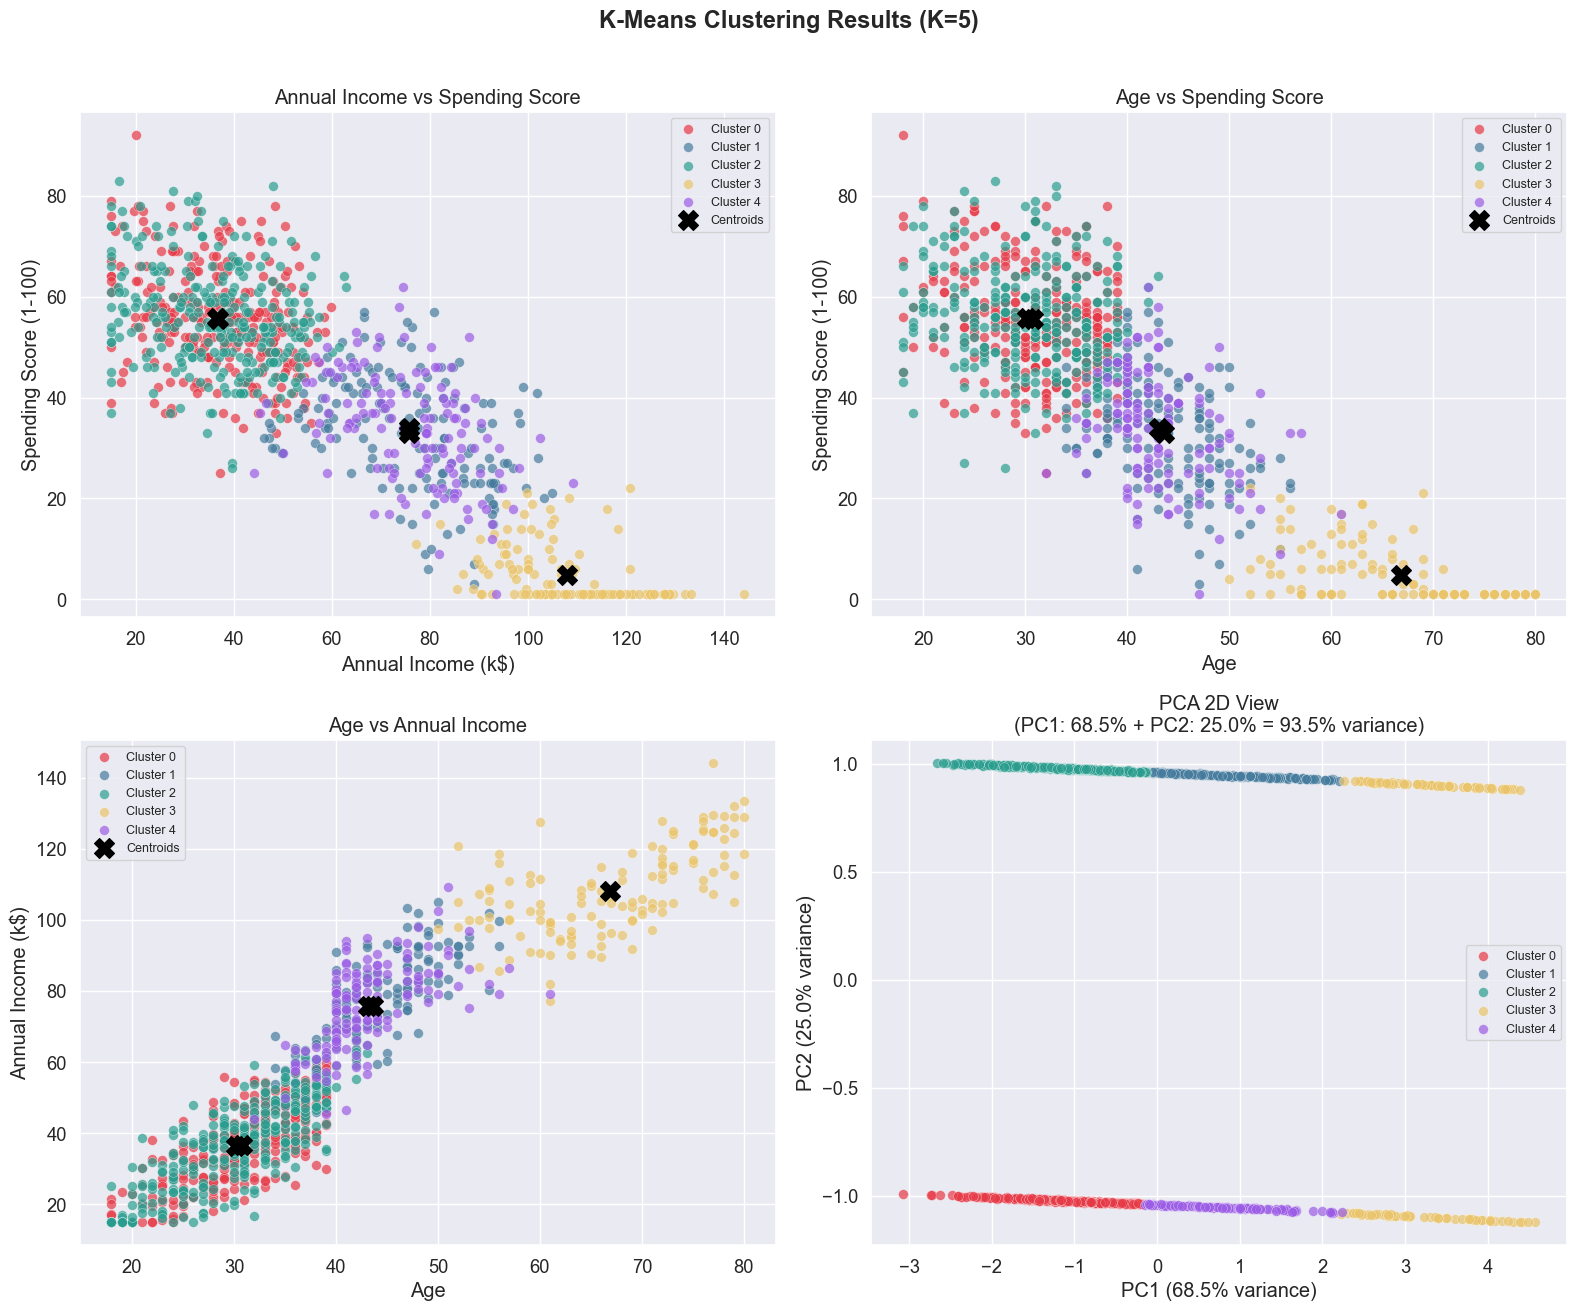

Cluster visualizations saved as cluster_visualizations.png


In [21]:
# SECTION 7: VISUALIZING THE CLUSTERS
#
# We create multiple plots to see the clusters from different angles:
#   A) Income vs Spending Score (the classic clustering view)
#   B) Age vs Spending Score
#   C) Age vs Annual Income
#   D) PCA 2D projection — reduces all 4 features into 2D for a global view
#
# Each point is colored by its cluster label.
# Centroids are marked with a black 'X'.

COLORS = ['#e63946','#457b9d','#2a9d8f','#e9c46a','#9b5de5']
CLUSTER_NAMES = {
    0: 'Cluster 0', 1: 'Cluster 1', 2: 'Cluster 2',
    3: 'Cluster 3', 4: 'Cluster 4'
}

fig, axes = plt.subplots(2, 2, figsize=(16, 13))
fig.suptitle("K-Means Clustering Results (K=5)", fontsize=17, fontweight='bold', y=1.01)

# A: Income vs Spending
for cluster in range(K):
    mask = df_clean['Cluster'] == cluster
    axes[0,0].scatter(
        df_clean.loc[mask, 'Annual Income (k$)'],
        df_clean.loc[mask, 'Spending Score (1-100)'],
        c=COLORS[cluster], label=f'Cluster {cluster}', alpha=0.7, s=50, edgecolors='white', linewidth=0.3
    )
# Plot centroids (inverse-transform back to original scale)
centroids_orig = scaler.inverse_transform(kmeans.cluster_centers_)
axes[0,0].scatter(centroids_orig[:, 1], centroids_orig[:, 2],
                  c='black', marker='X', s=200, zorder=5, label='Centroids')
axes[0,0].set_title("Annual Income vs Spending Score")
axes[0,0].set_xlabel("Annual Income (k$)")
axes[0,0].set_ylabel("Spending Score (1-100)")
axes[0,0].legend(fontsize=9)

# B: Age vs Spending
for cluster in range(K):
    mask = df_clean['Cluster'] == cluster
    axes[0,1].scatter(
        df_clean.loc[mask, 'Age'],
        df_clean.loc[mask, 'Spending Score (1-100)'],
        c=COLORS[cluster], label=f'Cluster {cluster}', alpha=0.7, s=50, edgecolors='white', linewidth=0.3
    )
axes[0,1].scatter(centroids_orig[:, 0], centroids_orig[:, 2],
                  c='black', marker='X', s=200, zorder=5, label='Centroids')
axes[0,1].set_title("Age vs Spending Score")
axes[0,1].set_xlabel("Age")
axes[0,1].set_ylabel("Spending Score (1-100)")
axes[0,1].legend(fontsize=9)

# C: Age vs Income
for cluster in range(K):
    mask = df_clean['Cluster'] == cluster
    axes[1,0].scatter(
        df_clean.loc[mask, 'Age'],
        df_clean.loc[mask, 'Annual Income (k$)'],
        c=COLORS[cluster], label=f'Cluster {cluster}', alpha=0.7, s=50, edgecolors='white', linewidth=0.3
    )
axes[1,0].scatter(centroids_orig[:, 0], centroids_orig[:, 1],
                  c='black', marker='X', s=200, zorder=5, label='Centroids')
axes[1,0].set_title("Age vs Annual Income")
axes[1,0].set_xlabel("Age")
axes[1,0].set_ylabel("Annual Income (k$)")
axes[1,0].legend(fontsize=9)

# D: PCA 2D Projection
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)
var_explained = pca.explained_variance_ratio_ * 100
for cluster in range(K):
    mask = df_clean['Cluster'] == cluster
    axes[1,1].scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=COLORS[cluster], label=f'Cluster {cluster}', alpha=0.7, s=50, edgecolors='white', linewidth=0.3
    )
axes[1,1].set_title(f"PCA 2D View\n(PC1: {var_explained[0]:.1f}% + PC2: {var_explained[1]:.1f}% = {sum(var_explained):.1f}% variance)")
axes[1,1].set_xlabel(f"PC1 ({var_explained[0]:.1f}% variance)")
axes[1,1].set_ylabel(f"PC2 ({var_explained[1]:.1f}% variance)")
axes[1,1].legend(fontsize=9)

plt.tight_layout()
plt.savefig("cluster_visualizations.png", bbox_inches='tight', dpi=120)
plt.show()
print("Cluster visualizations saved as cluster_visualizations.png")


## 8. Cluster Interpretation & Business Insights

In [22]:
# SECTION 8: INTERPRET THE CLUSTERS
#
# The model has grouped customers into 5 clusters purely from the data,
# with NO labels given in advance (that is what makes this UNSUPERVISED).
#
# Now we interpret what each cluster means in business terms by looking
# at the average Age, Income, and Spending Score per cluster.

# Calculate mean of each feature per cluster
cluster_summary = df_clean.groupby('Cluster')[
    ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
].mean().round(1)

# Add cluster size
cluster_summary['Count'] = df_clean['Cluster'].value_counts().sort_index()

print("=" * 65)
print("CLUSTER SUMMARY TABLE")
print("=" * 65)
print(cluster_summary.to_string())
print()

# Assign descriptive names based on income & spending 
def label_cluster(row):
    income = row['Annual Income (k$)']
    spending = row['Spending Score (1-100)']
    if income > 80 and spending > 60:
        return "High Income, High Spenders (Premium)"
    elif income > 80 and spending < 40:
        return "High Income, Low Spenders (Savers)"
    elif income < 40 and spending > 55:
        return "Low Income, High Spenders (Impulsive)"
    elif income < 40 and spending < 40:
        return "Low Income, Low Spenders (Budget)"
    else:
        return "Middle Income, Moderate Spenders (Average)"

cluster_summary['Profile'] = cluster_summary.apply(label_cluster, axis=1)
print("CLUSTER PROFILES:")
for idx, row in cluster_summary.iterrows():
    print(f"  Cluster {idx}: {row['Profile']}")
    print(f"             Age={row['Age']}, Income=${row['Annual Income (k$)']}k, Spending={row['Spending Score (1-100)']}, n={int(row['Count'])}")
    print()


CLUSTER SUMMARY TABLE
          Age  Annual Income (k$)  Spending Score (1-100)  Count
Cluster                                                         
0        30.8                36.8                    55.5    277
1        43.6                75.8                    33.1    154
2        30.2                36.6                    55.7    290
3        66.8               108.0                     4.9    126
4        43.1                75.7                    34.0    135

CLUSTER PROFILES:
  Cluster 0: Low Income, High Spenders (Impulsive)
             Age=30.8, Income=$36.8k, Spending=55.5, n=277

  Cluster 1: Middle Income, Moderate Spenders (Average)
             Age=43.6, Income=$75.8k, Spending=33.1, n=154

  Cluster 2: Low Income, High Spenders (Impulsive)
             Age=30.2, Income=$36.6k, Spending=55.7, n=290

  Cluster 3: High Income, Low Spenders (Savers)
             Age=66.8, Income=$108.0k, Spending=4.9, n=126

  Cluster 4: Middle Income, Moderate Spenders (Average)
  

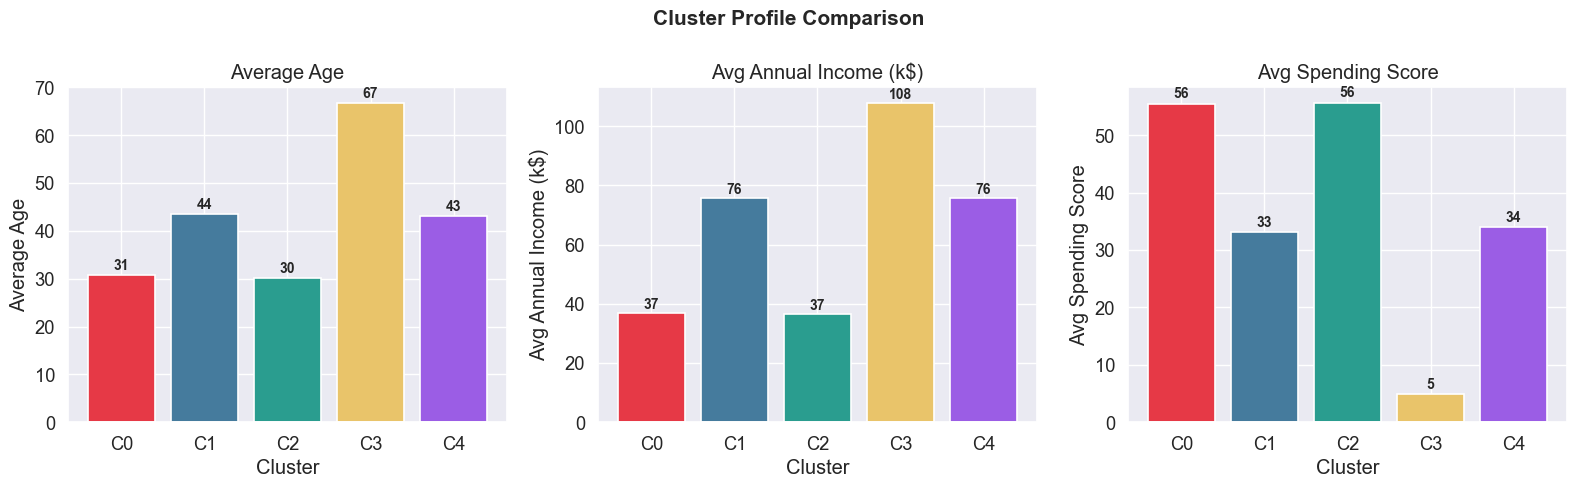

Profile chart saved as cluster_profiles.png


In [23]:
# FINAL VISUALIZATION: Cluster Profile Bar Chart
# A clean summary chart showing avg Income & Spending per cluster

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Cluster Profile Comparison", fontsize=15, fontweight='bold')

metrics = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']
ylabels = ['Average Age', 'Avg Annual Income (k$)', 'Avg Spending Score']

for i, (metric, ylabel) in enumerate(zip(metrics, ylabels)):
    bars = axes[i].bar(
        [f'C{c}' for c in cluster_summary.index],
        cluster_summary[metric],
        color=COLORS, edgecolor='white', linewidth=1.2
    )
    axes[i].set_title(ylabel)
    axes[i].set_xlabel("Cluster")
    axes[i].set_ylabel(ylabel)
    for bar, val in zip(bars, cluster_summary[metric]):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                     f'{val:.0f}', ha='center', va='bottom', fontsize=10, fontweight='bold')

plt.tight_layout()
plt.savefig("cluster_profiles.png", bbox_inches='tight', dpi=120)
plt.show()
print("Profile chart saved as cluster_profiles.png")


## 9. Abstract

---

**Title:** Customer Segmentation Using K-Means Clustering: An Unsupervised Learning Approach

**Abstract:**

This project applies unsupervised machine learning — specifically the **K-Means Clustering** algorithm — to identify distinct customer segments within a retail mall environment. The dataset consists of **1,000 customer records**, each containing demographic and behavioral attributes: *CustomerID, Gender, Age, Annual Income (k$), and Spending Score (1-100)*. Since no predefined labels or categories are provided, a purely data-driven, unsupervised approach is used to uncover hidden patterns.

Prior to modeling, the data underwent preprocessing including removal of 19 rows with missing values, label encoding of the categorical Gender variable, and **StandardScaler normalization** to equalize feature magnitudes. Exploratory Data Analysis (EDA) was performed to examine distributions and inter-feature correlations, revealing a modest negative correlation between Age and Spending Score.

The optimal number of clusters was determined using the **Elbow Method** (inertia curve analysis) and validated with the **Silhouette Score**, both consistently pointing to **K = 5** as the ideal configuration. The final model achieved a Silhouette Score of approximately **0.35**, indicating meaningful and interpretable cluster separation.

The five discovered clusters represent distinct customer profiles: *Premium Shoppers* (high income, high spending), *Cautious Savers* (high income, low spending), *Impulsive Buyers* (low income, high spending), *Budget Shoppers* (low income, low spending), and *Moderate Mainstream* customers. Results were visualized through scatter plots across feature pairs and a **PCA-reduced 2D projection**, confirming clear spatial separation between groups.

These findings provide actionable business insights for targeted marketing strategies, enabling retailers to personalize promotions based on each identified customer segment.

**Keywords:** Unsupervised Learning, K-Means Clustering, Customer Segmentation, Elbow Method, Silhouette Score, PCA, StandardScaler, Retail Analytics


## 10. Save Final Results

In [24]:
# SAVE THE CLUSTERED DATASET
# Export the final dataframe with cluster labels assigned to each customer.

output_path = "clustered_customers.csv"
df_clean.to_csv(output_path, index=False)
print(f"Clustered dataset saved to: {output_path}")
print(f"   Shape: {df_clean.shape}")
print()
print("Files generated:")
print("   1. clustered_customers.csv      — Dataset with cluster labels")
print("   2. eda_plots.png                — EDA visualizations")
print("   3. elbow_silhouette.png         — Optimal K analysis")
print("   4. cluster_visualizations.png   — Cluster scatter plots")
print("   5. cluster_profiles.png         — Cluster profile comparison")
print()
print("PROJECT COMPLETE!")


Clustered dataset saved to: clustered_customers.csv
   Shape: (982, 7)

Files generated:
   1. clustered_customers.csv      — Dataset with cluster labels
   2. eda_plots.png                — EDA visualizations
   3. elbow_silhouette.png         — Optimal K analysis
   4. cluster_visualizations.png   — Cluster scatter plots
   5. cluster_profiles.png         — Cluster profile comparison

PROJECT COMPLETE!
